In [11]:
from typing import TypedDict, Dict, List
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [12]:
class State(TypedDict):
    number1: int
    number2: int
    operation1: str
    finalNumber1: int
    number3: int
    number4: int
    operation2: str
    finalNumber2: int

In [14]:
def add_node1(state: State) -> State:
    state["finalNumber1"] = state["number1"]+state["number2"]
    return state

def subtract_node1(state: State) -> State:
    state["finalNumber1"] = state["number1"]-state["number2"]
    return state

def router1(state: State) -> State:
    if state["operation1"] == "+":
        return "addition_operation"
    elif state["operation1"] == "-":
        return "subtraction_operation"
    else:
        return "invalid response"

In [16]:
def add_node2(state: State) -> State:
    state["finalNumber2"] = state["number3"]+state["number4"]
    return state

def subtract_node2(state: State) -> State:
    state["finalNumber2"] = state["number3"]-state["number4"]
    return state

def router2(state: State) -> State:
    if state["operation2"] == "+":
        return "addition_operation2"
    elif state["operation2"] == "-":
        return "subtraction_operation2"
    else:
        return "invalid response"

In [ ]:
graph = StateGraph(State)
graph.add_node("router1", lambda state:state) # passthrough function as router function returns text (edge name) and not state
graph.add_edge(START,"router1") 
graph.add_node("add_node1", add_node1)
graph.add_node("subtract_node1", subtract_node1)
graph.add_conditional_edges(                  # defining conditional edge
    "router1",                                # Name of node from where edge is starting / source node
    router1,                                  # Name of the conditional node defined earlier
    {
        "addition_operation":"add_node1",     # Edge name from conditional node defined earlier: corresponding destination node
        "subtraction_operation":"subtract_node1"
    }
)
graph.add_node("router2", lambda state:state) # passthrough function as router function returns text (edge name) and not state
graph.add_edge("add_node1","router2")
graph.add_edge("subtract_node1","router2")
graph.add_node("add_node2", add_node2)
graph.add_node("subtract_node2", subtract_node2)
graph.add_conditional_edges(
    "router2", router2, 
    {
        "addition_operation2":"add_node2",
        "subtraction_operation2":"subtract_node2"
    }
)
graph.add_edge("add_node2",END)
graph.add_edge("subtract_node2",END)

app = graph.compile()

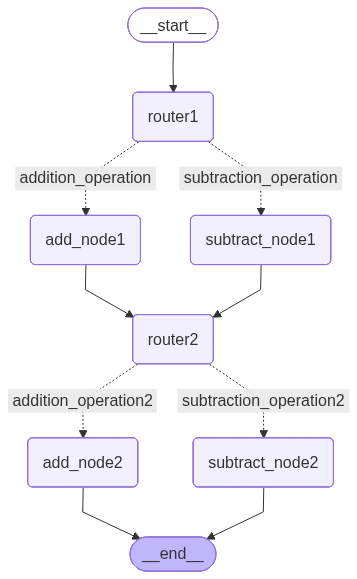

In [24]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [29]:
answer = app.invoke({"number1": 10,"number2":5,"operation1":"-","number3": 7,"number4":2,"operation2":"+"})
answer["finalNumber1"], answer["finalNumber2"]

(5, 9)